# Joint clustering - two breast cancer sections from Xenium

This notebook builds shared spatial structures for Xenium breast
cancer Rep1 and Rep2. It begins with the original combined
286,532-cell expression object, performs the selected sample-wise
QC and batch-aware HVG300 preprocessing, and then runs the
AnnData-native joint clustering workflow.

## Installation and input

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
export SPALIGNDE_BREAST_CANCER_INPUT=/path/to/xenium_rep1_rep2_joint_input.h5ad
```

Download In Situ Sample 1 Replicates 1 and 2 from the
[10x Genomics Xenium human-breast dataset](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast).

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")
warnings.filterwarnings("ignore", message="Some cells have zero counts")
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "legend.frameon": False,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "breast_cancer" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
input_value = os.environ.get("SPALIGNDE_BREAST_CANCER_INPUT")
if not input_value:
    raise EnvironmentError(
        "Set SPALIGNDE_BREAST_CANCER_INPUT to the original combined Xenium .h5ad"
    )
INPUT_PATH = Path(input_value).expanduser().resolve()
print("Input:", INPUT_PATH.name)

Input: xenium_breast_cancer_rep1_rep2_joint_input.h5ad


  from pkg_resources import get_distribution, DistributionNotFound


## Sample-wise QC and batch-aware HVG selection

Within each replicate, cells below the 10th percentile of
transcript count or outside the 1st-99th percentile ranges of cell
and nucleus area are removed. The top 300 highly variable genes are
then selected after total-count normalization and log
transformation, using `sample_id` as the batch key.

In [2]:
adata = spAlignDE.load_cross_sample_data(INPUT_PATH)
adata.obs["sample_id"] = adata.obs["sample_id"].astype(str)

thresholds = {}
keep = pd.Series(False, index=adata.obs_names)
summary_rows = []
for sample in sorted(adata.obs["sample_id"].unique()):
    sample_mask = adata.obs["sample_id"].eq(sample)
    obs = adata.obs.loc[sample_mask]
    values = {
        "transcript_counts_min": float(obs["transcript_counts"].quantile(0.10)),
        "cell_area_min": float(obs["cell_area"].quantile(0.01)),
        "cell_area_max": float(obs["cell_area"].quantile(0.99)),
        "nucleus_area_min": float(obs["nucleus_area"].quantile(0.01)),
        "nucleus_area_max": float(obs["nucleus_area"].quantile(0.99)),
    }
    thresholds[sample] = values
    pass_qc = (
        (obs["transcript_counts"] >= values["transcript_counts_min"])
        & (obs["cell_area"] >= values["cell_area_min"])
        & (obs["cell_area"] <= values["cell_area_max"])
        & (obs["nucleus_area"] >= values["nucleus_area_min"])
        & (obs["nucleus_area"] <= values["nucleus_area_max"])
    )
    keep.loc[obs.index] = pass_qc.to_numpy()
    summary_rows.append({
        "sample_id": sample,
        "n_cells_before": int(len(obs)),
        "n_cells_after_qc": int(pass_qc.sum()),
        **values,
    })

qc = adata[keep.to_numpy()].copy()
normalized = qc.copy()
sc.pp.normalize_total(normalized, target_sum=1e4)
sc.pp.log1p(normalized)
sc.pp.highly_variable_genes(
    normalized,
    n_top_genes=300,
    flavor="seurat",
    batch_key="sample_id",
)
hvg_mask = normalized.var["highly_variable"].to_numpy()
adata_filtered = qc[:, hvg_mask].copy()
adata_filtered.uns["qc_thresholds"] = thresholds
adata_filtered.uns["filtering"] = {
    "qc_transcript_min_quantile": 0.10,
    "qc_area_low_quantile": 0.01,
    "qc_area_high_quantile": 0.99,
    "hvg_n_top": int(hvg_mask.sum()),
    "hvg_batch_key": "sample_id",
}
print(pd.DataFrame(summary_rows))
print(adata_filtered)

  sample_id  n_cells_before  n_cells_after_qc  transcript_counts_min  \
0      Rep1          167780            147333                   54.0   
1      Rep2          118752            104365                   62.0   

   cell_area_min  cell_area_max  nucleus_area_min  nucleus_area_max  
0      23.661875     907.733195          5.870312        142.242188  
1      24.655313    1007.095911          5.870312        142.941658  
AnnData object with n_obs × n_vars = 251698 × 300
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id'
    uns: 'qc_thresholds', 'filtering'
    obsm: 'spatial'


## Run the selected joint clustering model

The selected breast-cancer setting uses BANKSY lambda 1.0,
Harmony theta 4.0 and Leiden resolution 0.2.

In [3]:
config = spAlignDE.JointClusteringConfig(
    num_neighbors=30,
    banksy_lambda=1.0,
    pca_dim=20,
    resolution=0.2,
    snn_neighbors=50,
    harmony_theta=4.0,
    harmony_max_iter=30,
    refine_boundaries=True,
    compute_umap=False,
    random_state=1000,
)
adata_clustered, clustering_details = spAlignDE.cluster_joint(
    adata_filtered,
    config=config,
    return_details=True,
)
print("Raw clusters:", adata_clustered.obs["cluster_raw"].nunique())
print("Refined clusters:", adata_clustered.obs["cluster_refined"].nunique())
print(
    adata_clustered.obs.groupby(
        ["sample_id", "cluster"], observed=False
    ).size().unstack(fill_value=0)
)


Median distance to closest cell = 9.814910038787898

---- Ran median_dist_to_nearest_neighbour in 0.47 s ----



---- Ran generate_spatial_distance_graph in 1.44 s ----



---- Ran row_normalize in 0.54 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 4.75 s ----



---- Ran generate_spatial_distance_graph in 2.14 s ----



---- Ran theta_from_spatial_graph in 1.28 s ----



...

Current decay types: ['scaled_gaussian']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 1.0)

Setting the total number of PC = 20


Original shape of matrix: (251698, 900)
Reduced shape of matrix: (251698, 20)
------------------------------------------------------------
min_value = -19.61557914375831, mean = -9.052109729830618e-15, max = 49.99776190878578



2026-07-31 11:19:39,725 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-07-31 11:19:40,976 - harmonypy - INFO - KMeans initialization complete.


Raw clusters: 5
Refined clusters: 5
cluster        0      1      2     3     4
sample_id                                 
Rep1       60126  49311  32532  5298    66
Rep2       47463  23929  25502  6254  1217


### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect raw and refined breast-cancer structures

Rep1 and Rep2 are shown in columns. Raw and boundary-refined
clusters are shown in rows with one shared color map.

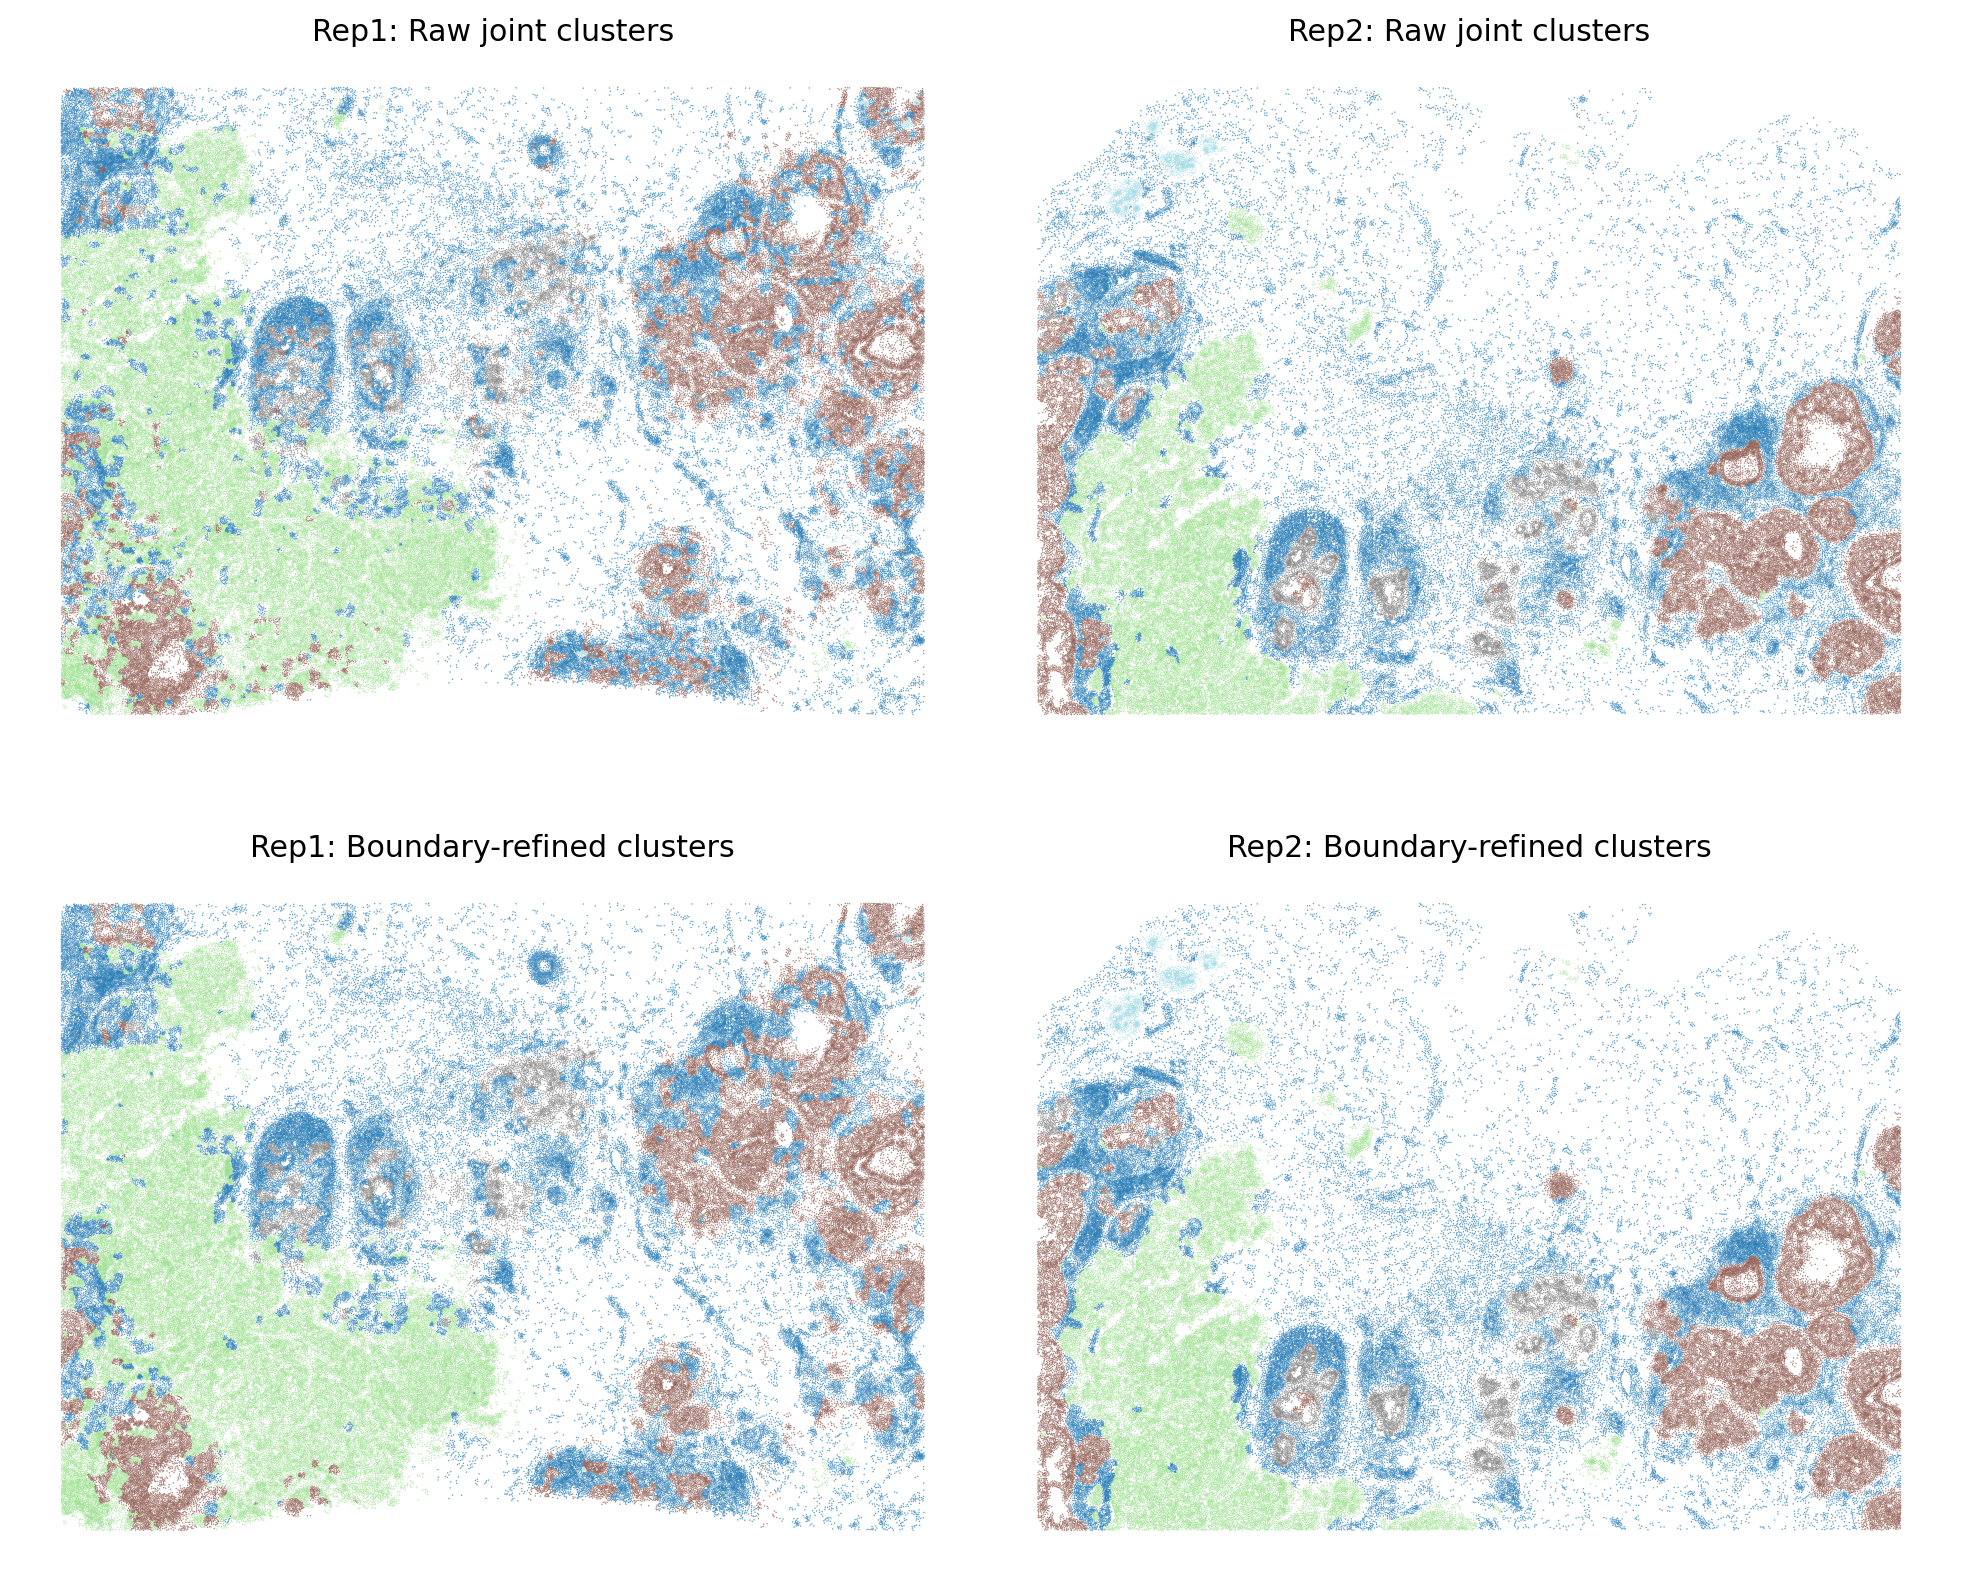

,n_cells,n_changed,pct_changed,n_boundary,n_boundary_changed,n_protected_changed
Rep1,147333.0,13300.0,0.090272,4475.0,12.0,24.0
Rep2,104365.0,3617.0,0.034657,3926.0,3.0,10.0


In [4]:
fig, axes = spAlignDE.plot_joint_cluster_refinement(
    adata_clustered,
    samples=["Rep1", "Rep2"],
    point_size=0.35,
    palette="tab20",
    alpha=0.7,
)
plt.show()
clustering_details["refinement_stats"]

## Save the clustered breast-cancer AnnData

The refined `cluster` column is the semantic input to the Rep2 to
Rep1 alignment notebook.

In [5]:
clustered_path = OUTPUT_DIR / "breast_cancer_Rep1_Rep2_joint_clustered.h5ad"
adata_clustered.write_h5ad(clustered_path)
print("Saved:", clustered_path.relative_to(PROJECT_ROOT))
print("Output shape:", adata_clustered.shape)
print("Cluster columns:", ["cluster_raw", "cluster_refined", "cluster"])

Saved: tutorials/cross_sample/breast_cancer/output/breast_cancer_Rep1_Rep2_joint_clustered.h5ad
Output shape: (251698, 300)
Cluster columns: ['cluster_raw', 'cluster_refined', 'cluster']
